# Reto 4 – Integrador de resultados

**Objetivo:** Combinar los análisis de los compañeros y crear un resumen general del ecosistema.

Carga el conjunto de datos y explora las variables relevantes.

In [1]:
import pandas as pd

df = pd.read_csv("../data/resultados_experimentos.csv")
df.head()

,sitio,temperatura,humedad,luz,biomasa
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8
1,Humedal Facatativá,18.0,89.7,395,225.8
2,Río San Francisco,17.2,85.4,647,237.5
3,Ladera de La Vega,21.7,81.4,769,252.4
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7


## Exploración inicial
Describe las columnas y analiza los tipos de datos.

In [12]:
print("Columnas del Reto 1:")
print(df1.columns)

print("\nColumnas del Reto 2:")
print(df2.columns)

print("\nColumnas del Reto 3:")
print(df3.columns)

print("\nInformación del Reto 1:")
df1.info()

print("\nInformación del Reto 2:")
df2.info()

print("\nInformación del Reto 3:")
df3.info()

Columnas del Reto 1:
Index(['sitio', 'temperatura', 'humedad', 'luz', 'biomasa', 'categoria_clima'], dtype='object')

Columnas del Reto 2:
Index(['sitio', 'temperatura', 'humedad', 'luz', 'biomasa', 'indice_luz',
       'categoria_luz', 'nivel_biomasa'],
      dtype='object')

Columnas del Reto 3:
Index(['sitio', 'temperatura', 'humedad', 'luz', 'biomasa', 'nivel_biomasa'], dtype='object')

Información del Reto 1:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sitio            20 non-null     object 
 1   temperatura      20 non-null     float64
 2   humedad          20 non-null     float64
 3   luz              20 non-null     int64  
 4   biomasa          20 non-null     float64
 5   categoria_clima  20 non-null     object 
dtypes: float64(3), int64(1), object(2)
memory usage: 1.1+ KB

Información del Reto 2:
<class 'pandas.core.frame

In [13]:
df1["categoria_clima"].value_counts()

categoria_clima
húmedo templado    11
húmedo frío         9
Name: count, dtype: int64

In [14]:
df2["categoria_luz"].value_counts()

categoria_luz
alta     7
baja     7
media    6
Name: count, dtype: int64

In [15]:
df3["nivel_biomasa"].value_counts()

nivel_biomasa
alta     7
baja     7
media    6
Name: count, dtype: int64

## Desarrollo del reto
Aplica funciones y análisis según el objetivo. Usa `def` para definir tus funciones.

In [16]:
df1.columns = df1.columns.str.strip().str.lower()
df2.columns = df2.columns.str.strip().str.lower()
df3.columns = df3.columns.str.strip().str.lower()

def integrar_datos(df1, df2, df3):
    df_integrado = df1.copy()

    df_reto2 = df2[["sitio", "indice_luz", "categoria_luz"]].copy()
    df_integrado = df_integrado.merge(df_reto2, on="sitio", how="left")

    df_reto3 = df3[["sitio", "nivel_biomasa"]].copy()
    df_integrado = df_integrado.merge(df_reto3, on="sitio", how="left")

    return df_integrado

df_integrado = integrar_datos(df1, df2, df3)

df_integrado.head()

,sitio,temperatura,humedad,luz,biomasa,categoria_clima,indice_luz,categoria_luz,nivel_biomasa
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8,húmedo templado,0.695007,alta,alta
1,Humedal Facatativá,18.0,89.7,395,225.8,húmedo frío,0.266532,baja,media
2,Río San Francisco,17.2,85.4,647,237.5,húmedo frío,0.436572,baja,media
3,Ladera de La Vega,21.7,81.4,769,252.4,húmedo templado,0.518893,baja,alta
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7,húmedo templado,0.899460,alta,alta


In [17]:
print("Filas Reto 1:", len(df1))
print("Filas integrado:", len(df_integrado))

print("\nColumnas del resultado integrado:")
print(df_integrado.columns)

print("\nValores nulos:")
display(df_integrado.isnull().sum())

Filas Reto 1: 20
Filas integrado: 20

Columnas del resultado integrado:
Index(['sitio', 'temperatura', 'humedad', 'luz', 'biomasa', 'categoria_clima',
       'indice_luz', 'categoria_luz', 'nivel_biomasa'],
      dtype='object')

Valores nulos:


sitio              0
temperatura        0
humedad            0
luz                0
biomasa            0
categoria_clima    0
indice_luz         0
categoria_luz      0
nivel_biomasa      0
dtype: int64

In [18]:
resumen_integrado = df_integrado.groupby(
    ["categoria_clima", "categoria_luz", "nivel_biomasa"]
).size().reset_index(name="numero_sitios")

resumen_integrado

,categoria_clima,categoria_luz,nivel_biomasa,numero_sitios
0,húmedo frío,alta,baja,1
1,húmedo frío,alta,media,1
2,húmedo frío,baja,baja,3
3,húmedo frío,baja,media,2
4,húmedo frío,media,alta,1
5,húmedo frío,media,media,1
6,húmedo templado,alta,alta,3
7,húmedo templado,alta,baja,2
8,húmedo templado,baja,alta,1
9,húmedo templado,baja,media,1


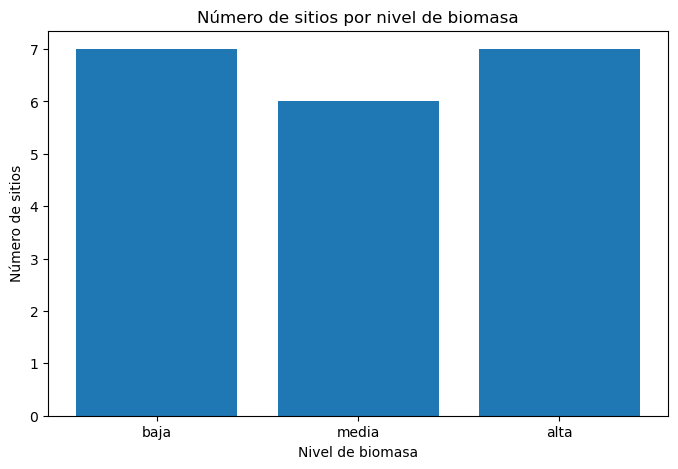

In [19]:
conteo_biomasa = df_integrado.groupby("nivel_biomasa").size().reset_index(name="numero_sitios")

orden = ["baja", "media", "alta"]

conteo_biomasa["nivel_biomasa"] = pd.Categorical(
    conteo_biomasa["nivel_biomasa"],
    categories=orden,
    ordered=True
)

conteo_biomasa = conteo_biomasa.sort_values("nivel_biomasa")

plt.figure(figsize=(8, 5))
plt.bar(
    conteo_biomasa["nivel_biomasa"].astype(str),
    conteo_biomasa["numero_sitios"]
)

plt.title("Número de sitios por nivel de biomasa")
plt.xlabel("Nivel de biomasa")
plt.ylabel("Número de sitios")
plt.show()

In [21]:
df_integrado.to_csv("../data/resultado_integrado.csv", index=False)

print("Archivo resultado_integrado.csv generado correctamente.")

Archivo resultado_integrado.csv generado correctamente.


## Interpretación de resultados
Escribe tus observaciones y conclusiones sobre los patrones encontrados.